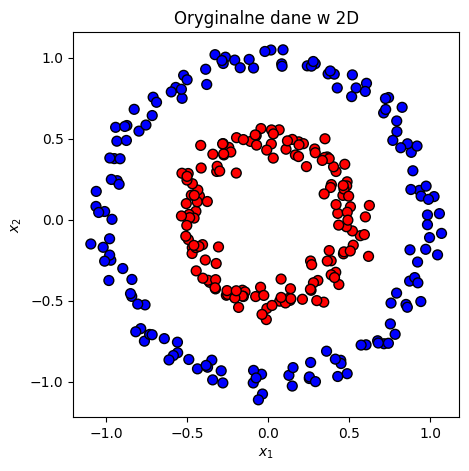

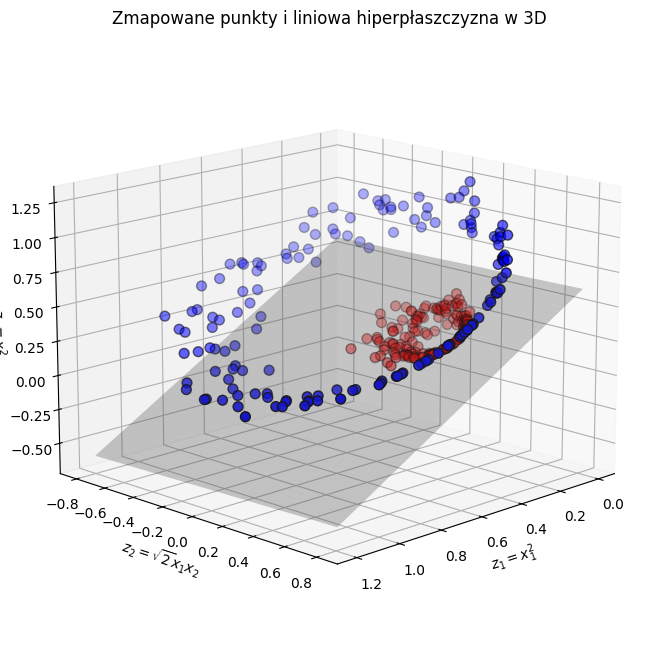

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

np.random.seed(42)
X, y = make_circles(n_samples=300, factor=0.5, noise=0.05)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=50)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Oryginalne dane w 2D')
plt.gca().set_aspect('equal')
plt.show()

#transformacja 2D -> 3D za pomocą funkcji phi
def phi(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.column_stack((x1**2, np.sqrt(2)*x1*x2, x2**2))

X_3d = phi(X)

clf = SVC(kernel='linear', C=1e5)
clf.fit(X_3d, y)

w = clf.coef_[0]      # [w1, w2, w3]
b = clf.intercept_[0] # bias

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, cmap='bwr', edgecolors='k', s=50)


z1_min, z1_max = X_3d[:, 0].min(), X_3d[:, 0].max()
z2_min, z2_max = X_3d[:, 1].min(), X_3d[:, 1].max()

zz1, zz2 = np.meshgrid(np.linspace(z1_min, z1_max, 50), np.linspace(z2_min, z2_max, 50))
zz3 = -(w[0]*zz1 + w[1]*zz2 + b) / w[2]

ax.plot_surface(zz1, zz2, zz3, alpha=0.3, color='gray')

ax.set_xlabel('$z_1 = x_1^2$')
ax.set_ylabel('$z_2 = \\sqrt{2}x_1x_2$')
ax.set_zlabel('$z_3 = x_2^2$')
ax.set_title('Zmapowane punkty i liniowa hiperpłaszczyzna w 3D')

ax.view_init(elev=15, azim=45)
plt.show()

In [6]:
import numpy as np

acc = clf.score(X_3d, y)
print(f"wyniki klasyfikacji")
print(f"Dokładność w 3D: {acc * 100:.2f}")

print("\nparametry hiperplaszczyzny")
print(f"w1 (waga dla x1^2)       = {w1:.4f}")
print(f"w2 (waga dla sqrt(2)x1x2)= {w2:.4f}")
print(f"w3 (waga dla x2^2)       = {w3:.4f}")
print(f"b (bias)                 = {b_val:.4f}")

print("\nprzeciwobraz w 2D")
print(f"{w1:.4f}*x1^2 + {w2:.4f}*sqrt(2)*x1*x2 + {w3:.4f}*x2^2 + ({b_val:.4f}) = 0")


wyniki klasyfikacji
Dokładność w 3D: 100.00

parametry hiperplaszczyzny
w1 (waga dla x1^2)       = -5.4689
w2 (waga dla sqrt(2)x1x2)= 0.1261
w3 (waga dla x2^2)       = -5.5377
b (bias)                 = 3.3929

przeciwobraz w 2D
-5.4689*x1^2 + 0.1261*sqrt(2)*x1*x2 + -5.5377*x2^2 + (3.3929) = 0


## Odpowiedzi na pytania (Primary & Secondary Question)

### Główne pytanie (Primary Question)
**Jaki jest przeciwobraz hiperpłaszczyzny w 2D i dlaczego granica decyzyjna nie jest "płaska"?**

W przestrzeni 3D, po transformacji zdefiniowanej jako $\phi(x_1, x_2) = (x_1^2, \sqrt{2}x_1x_2, x_2^2) = (z_1, z_2, z_3)$, klasyfikator SVM znajduje płaską, liniową hiperpłaszczyznę o równaniu:
$$w_1 z_1 + w_2 z_2 + w_3 z_3 + b = 0$$

Aby znaleźć przeciwobraz tej hiperpłaszczyzny w oryginalnej przestrzeni 2D, musimy podstawić zdefiniowane w transformacji $\phi$ oryginalne cechy z powrotem do powyższego równania:
$$w_1 x_1^2 + w_2 \sqrt{2}x_1 x_2 + w_3 x_2^2 + b = 0$$

Powyższe równanie jest szukanym przeciwobrazem. Wyjaśnia ono również, dlaczego granica decyzyjna widoczna na oryginalnym wykresie 2D nie jest "płaska". Mimo że w wyżej wymiarowej przestrzeni cech powierzchnia separująca jest liniowa, to z perspektywy oryginalnych zmiennych $x_1$ i $x_2$ otrzymujemy równanie algebraiczne drugiego stopnia. Rozwiązaniem równania drugiego stopnia na płaszczyźnie z definicji jest krzywa, a nie prosta linia.

---

### Pytanie pomocnicze (Secondary Question)
**Dlaczego i w jaki sposób hiperpłaszczyzna w 3D staje się okręgiem/elipsą w 2D?**

Z geometrycznego punktu widzenia, ogólne równanie kwadratowe postaci $Ax^2 + Bxy + Cy^2 + D = 0$ opisuje rodzinę krzywych stożkowych. W przestrzeni 3D nasze dane po transformacji układają się na powierzchni przypominającej paraboloidę. Przecięcie płaskiej hiperpłaszczyzny decyzyjnej z tą paraboloidą tworzy przestrzenną krzywą zamkniętą. Kiedy spojrzymy na nią "z góry krzywa ta przyjmuje kształt okręgu lub elipsy.

**Dowód empiryczny na podstawie wytrenowanego modelu:**
Algorytm SVM uruchomiony w naszym notatniku wyznaczył następujące parametry hiperpłaszczyzny:
* Waga dla $x_1^2$ to $w_1 \approx -5.47$
* Waga dla $x_2^2$ to $w_3 \approx -5.54$
* Waga dla $\sqrt{2}x_1 x_2$ to $w_2 \approx 0.12$
* Bias $b \approx 3.39$

Jak widać, waga składowej mieszanej ($w_2$) jest bliska zeru. Z kolei wagi przy kwadratach zmiennych ($w_1$ i $w_3$) mają ten sam znak i są niemal identyczne ($w_1 \approx w_3$). Oznacza to, że nasze równanie przeciwobrazu można przybliżyć jako:
$$w_1 x_1^2 + w_1 x_2^2 + b \approx 0$$
Co po przekształceniu daje kanoniczne równanie okręgu:
$$x_1^2 + x_2^2 \approx \frac{-b}{w_1}$$

Promień wyliczony z naszego modelu wynosi $r \approx 0.785$. Jest to optymalny margines, który układa się idealnie pośrodku pomiędzy wewnętrzną klasą danych (promień $\sim 0.5$) a zewnętrzną klasą (promień $\sim 1.0$).